# Tweet Sentiment Analyzer

A reproducible walkthrough. The outputs below are executed results from the pinned public dataset. See the README for full attribution and limitations.

## 1. Reproduce the pipeline

This invokes the same reusable code as the command line. Downloads are verified; cached data work offline.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the repository root or notebooks directory.")
sys.path.insert(0, str(ROOT))
from src.sentiment import run
metrics = run()

{
  "training_labels_for_baseline": 45615,
  "validation_tweets": 2000,
  "test_tweets": 12284,
  "selected_threshold": 0.2,
  "selection_metric": "validation macro F1; fixed grid; smallest threshold breaks ties",
  "validation_macro_f1": 0.4924378562595446,
  "test": {
    "accuracy": 0.5193747964832303,
    "macro_precision": 0.537334817845262,
    "macro_recall": 0.47806251831756635,
    "macro_f1": 0.4552173361533387,
    "classification_report": {
      "negative": {
        "precision": 0.6729222520107239,
        "recall": 0.18957703927492447,
        "f1-score": 0.2958161461402475,
        "support": 3972.0
      },
      "neutral": {
        "precision": 0.5430592827518907,
        "recall": 0.7498736735725113,
        "f1-score": 0.6299257163070393,
        "support": 5937.0
      },
      "positive": {
        "precision": 0.39602291877317153,
        "recall": 0.49473684210526314,
        "f1-score": 0.4399101460127293,
        "support": 2375.0
      },
      "accuracy": 0

## 2. Inspect the evidence

Only validation macro F1 selects the neutral band. The test set is evaluated afterwards. TextBlob supplies an existing lexicon rather than a newly fitted classifier.

In [2]:
pd.read_csv(ROOT / "reports/threshold_search.csv")

,threshold,validation_macro_f1
0,0.00,0.476515
1,0.05,0.479208
2,0.10,0.486307
3,0.15,0.488475
4,0.20,0.492438
5,0.25,0.476091
6,0.30,0.465443
7,0.40,0.406169
8,0.50,0.346151


In [3]:
pd.DataFrame({name: {k: v for k, v in metrics[key].items() if k != "classification_report"}
              for name, key in [("TextBlob", "test"), ("Majority baseline", "majority_baseline_test")]})

,TextBlob,Majority baseline
accuracy,0.519375,0.483312
macro_precision,0.537335,0.161104
macro_recall,0.478063,0.333333
macro_f1,0.455217,0.217222


In [4]:
pd.DataFrame(metrics["test"]["classification_report"]).T

,precision,recall,f1-score,support
negative,0.672922,0.189577,0.295816,3972.000000
neutral,0.543059,0.749874,0.629926,5937.000000
positive,0.396023,0.494737,0.439910,2375.000000
accuracy,0.519375,0.519375,0.519375,0.519375
macro avg,0.537335,0.478063,0.455217,12284.000000
weighted avg,0.556622,0.519375,0.485154,12284.000000


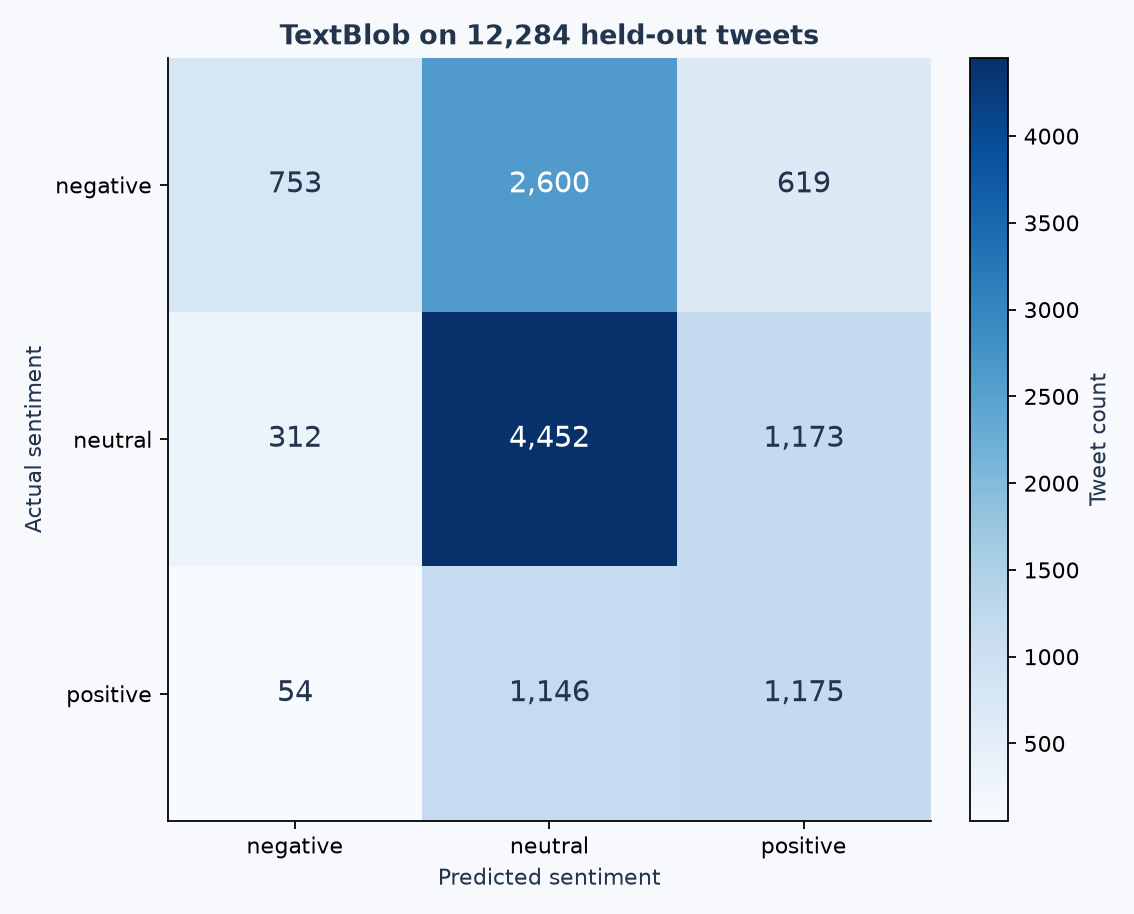

In [5]:
display(Image(filename=str(ROOT / "reports/confusion_matrix.png")))

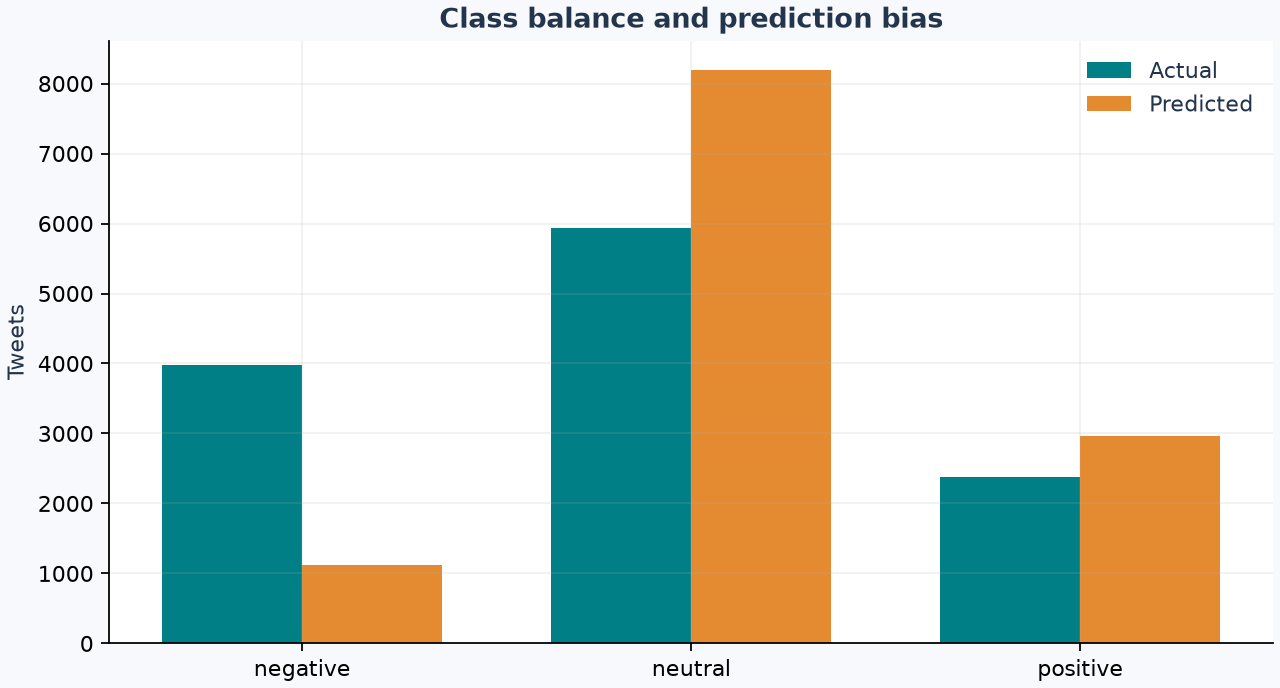

In [6]:
display(Image(filename=str(ROOT / "reports/sentiment_distribution.png")))

## 3. Hand-authored demonstration cases

These examples are illustrative only. They do not contribute to any benchmark metric. Notice that a sarcastic positive word can mislead the lexicon.

In [7]:
from src.sentiment import analyze
examples = ["I love this update!", "This is terrible.", "The meeting starts at noon.", "Great, another delayed train.", "This is not good."]
pd.DataFrame([{"input": text, **analyze(text)} for text in examples])

,input,cleaned_text,polarity,sentiment,threshold,note
0,I love this update!,I love this update!,0.625,positive,0.2,"Sentiment polarity, not emotion or confidence."
1,This is terrible.,This is terrible.,-1.000,negative,0.2,"Sentiment polarity, not emotion or confidence."
2,The meeting starts at noon.,The meeting starts at noon.,0.000,neutral,0.2,"Sentiment polarity, not emotion or confidence."
3,"Great, another delayed train.","Great, another delayed train.",0.800,positive,0.2,"Sentiment polarity, not emotion or confidence."
4,This is not good.,This is not good.,-0.350,negative,0.2,"Sentiment polarity, not emotion or confidence."


## Interpretation

Macro precision is 53.7%, macro F1 is 0.455, and accuracy is 51.9%. Negative recall is only 19.0%; the model misses much negative sentiment. This limitation is useful portfolio evidence when clearly explained. The original test split retains duplicates. Polarity is not confidence, and sentiment is not emotion.

Next: fit a TF-IDF/logistic-regression comparison on training data, select using validation, and reserve a fresh evaluation set for iterative work.